# Plot Learning Curves

In [100]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pmind.plot.learning_curves import (
    load_results,
    plot_learning_curves,
    plot_rb_compositions
)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [115]:
ENV_NAMES = (
    # "CartPoleContinuous-v1",
    "Pendulum-v1",
    "MountainCarContinuous-v0",
    # "LunarLanderContinuous-v3",
)
INPUT_DIR = ("../scripts/results/",
             "../results/test_rb_compositions-selected")[0]

In [129]:
all_performances = load_results(ENV_NAMES, INPUT_DIR, from_single_experiments=True)

results-Pendulum-v1--145
results-Pendulum-v1--233
results-MountainCarContinuous-v0-61
results-MountainCarContinuous-v0-35
results-MountainCarContinuous-v0-82
results-MountainCarContinuous-v0-61
results-MountainCarContinuous-v0-35
results-MountainCarContinuous-v0-82


=========== UNIFORM_PROPORTIONS =============


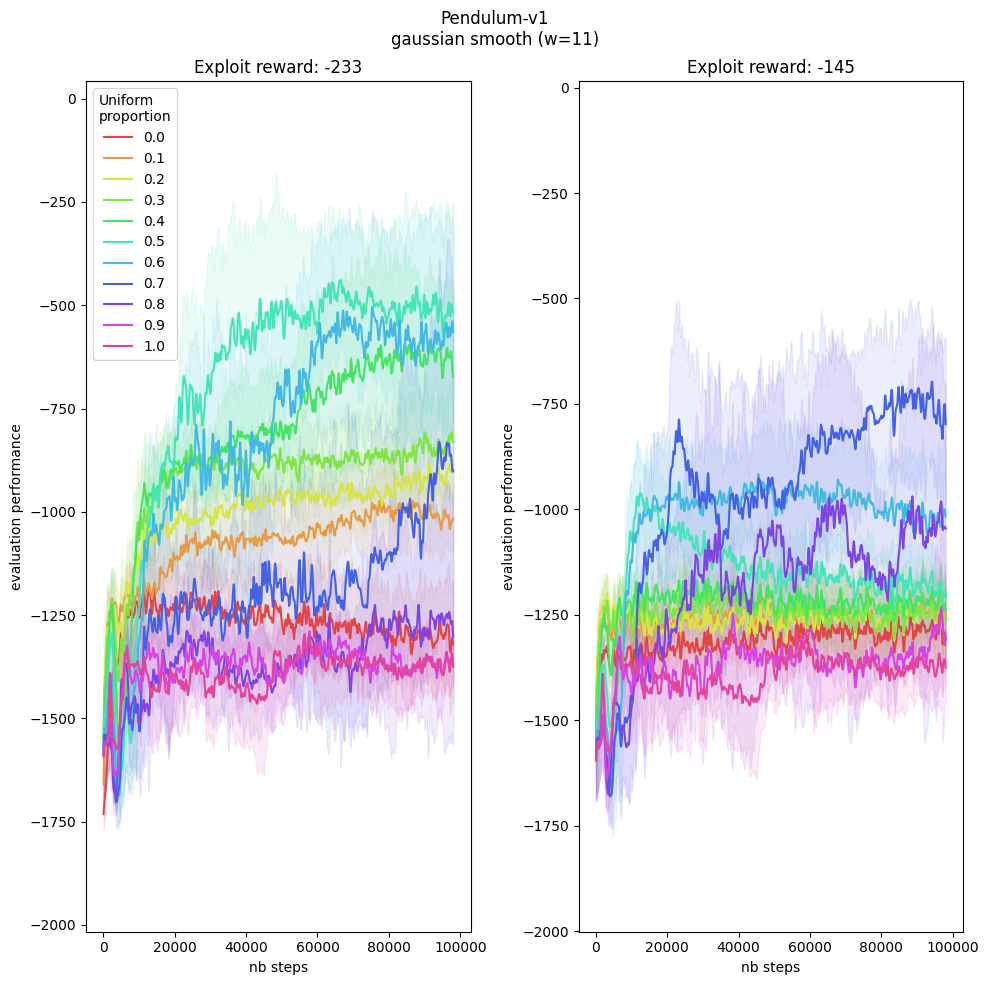

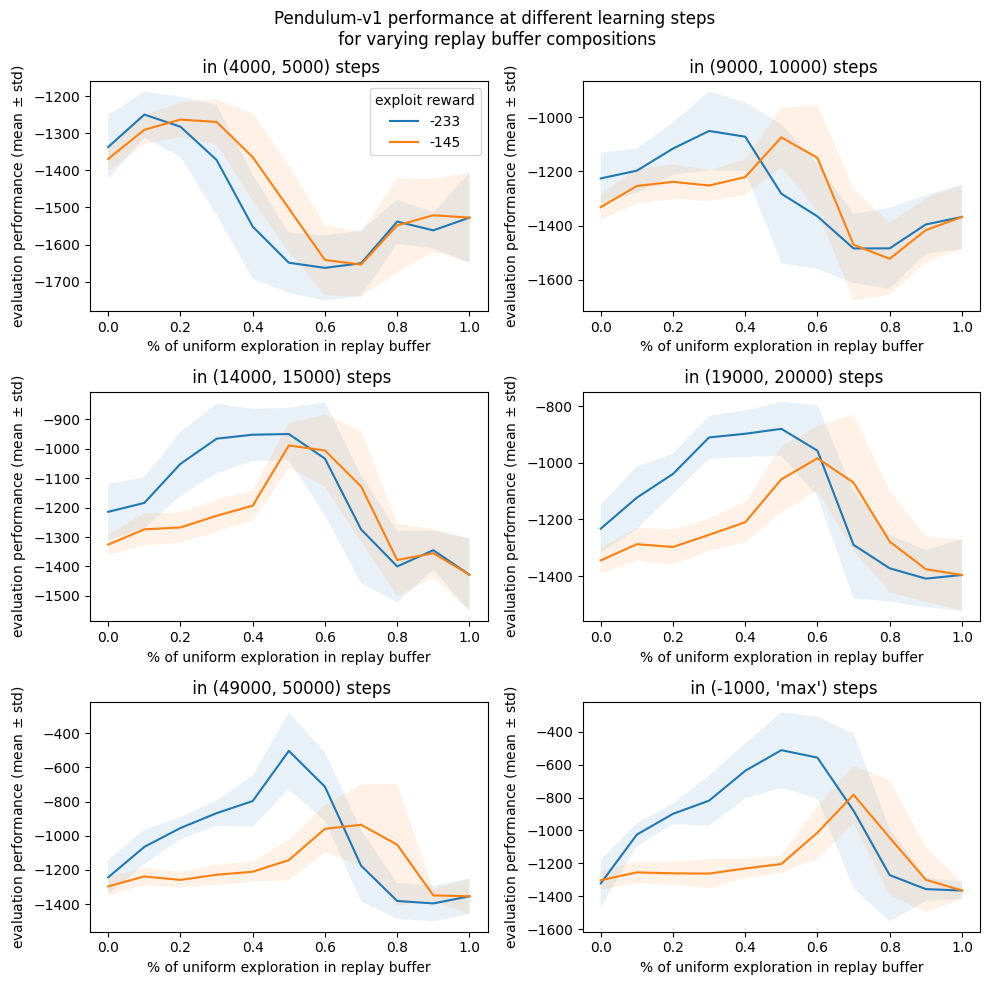

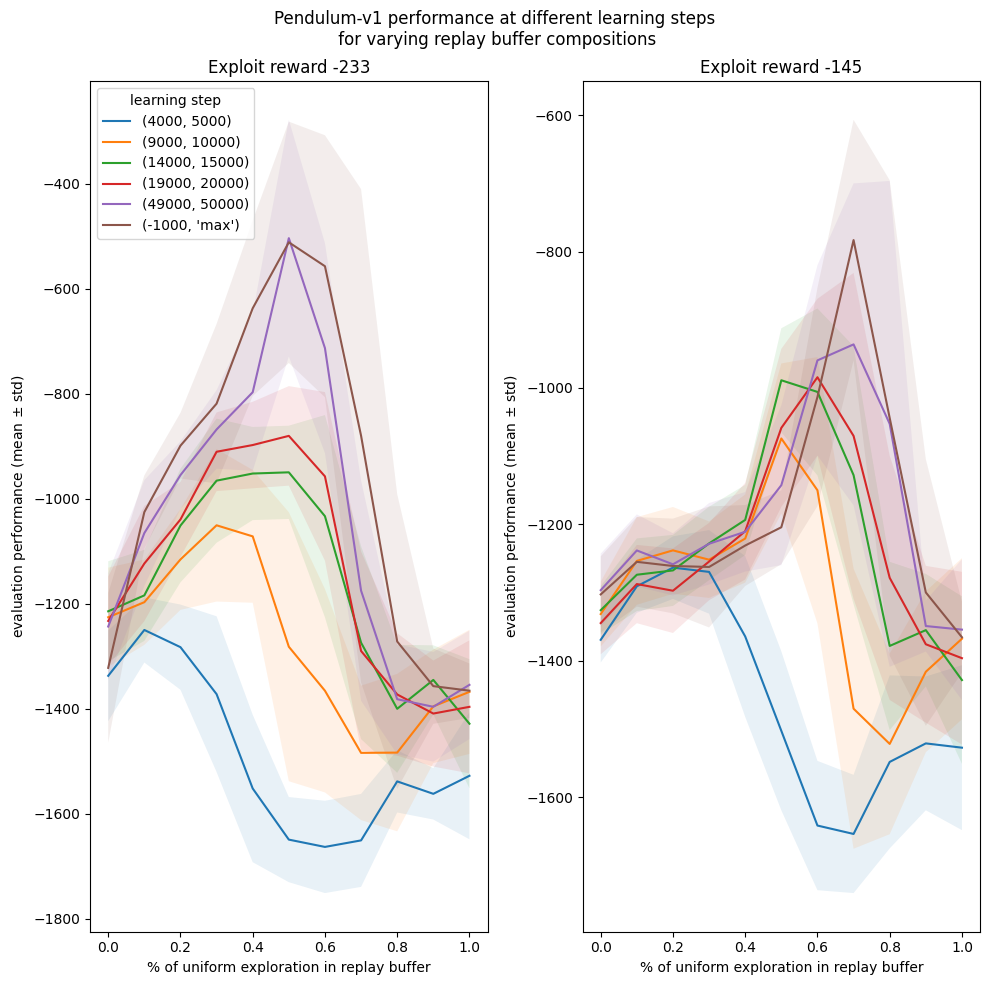

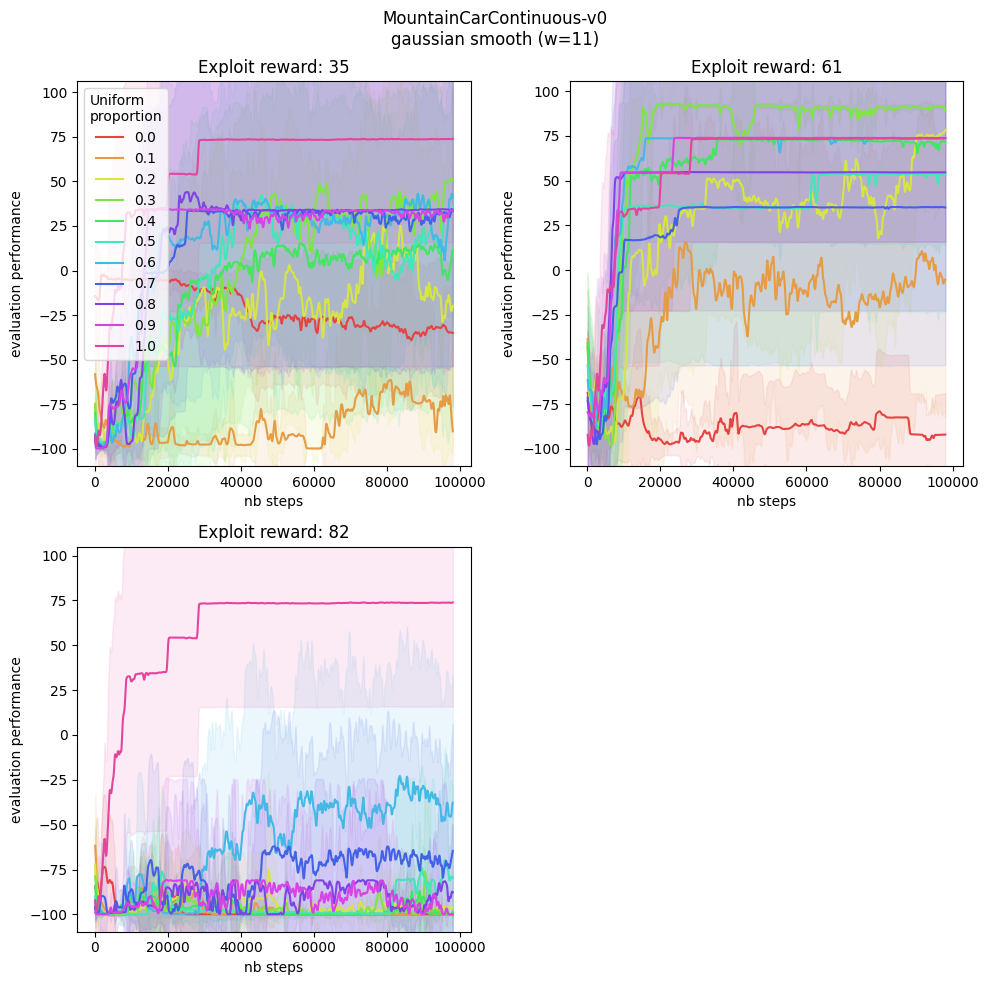

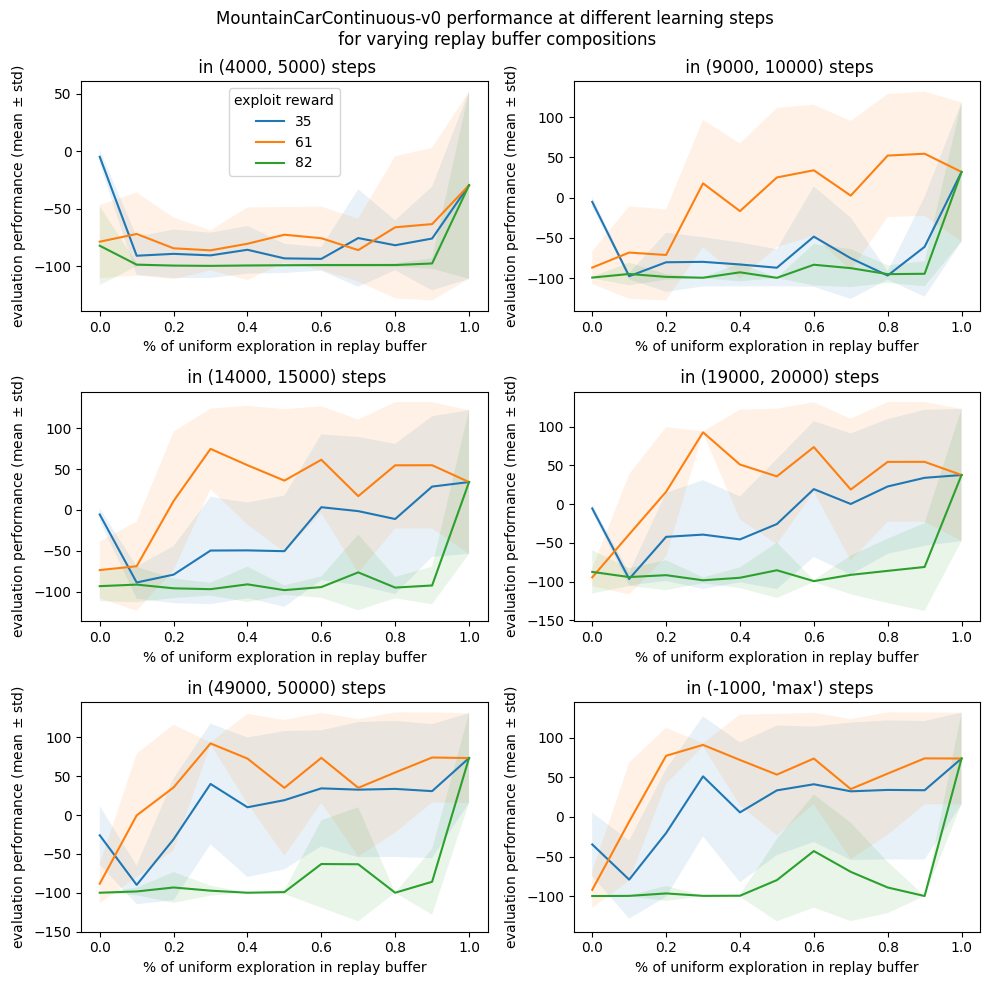

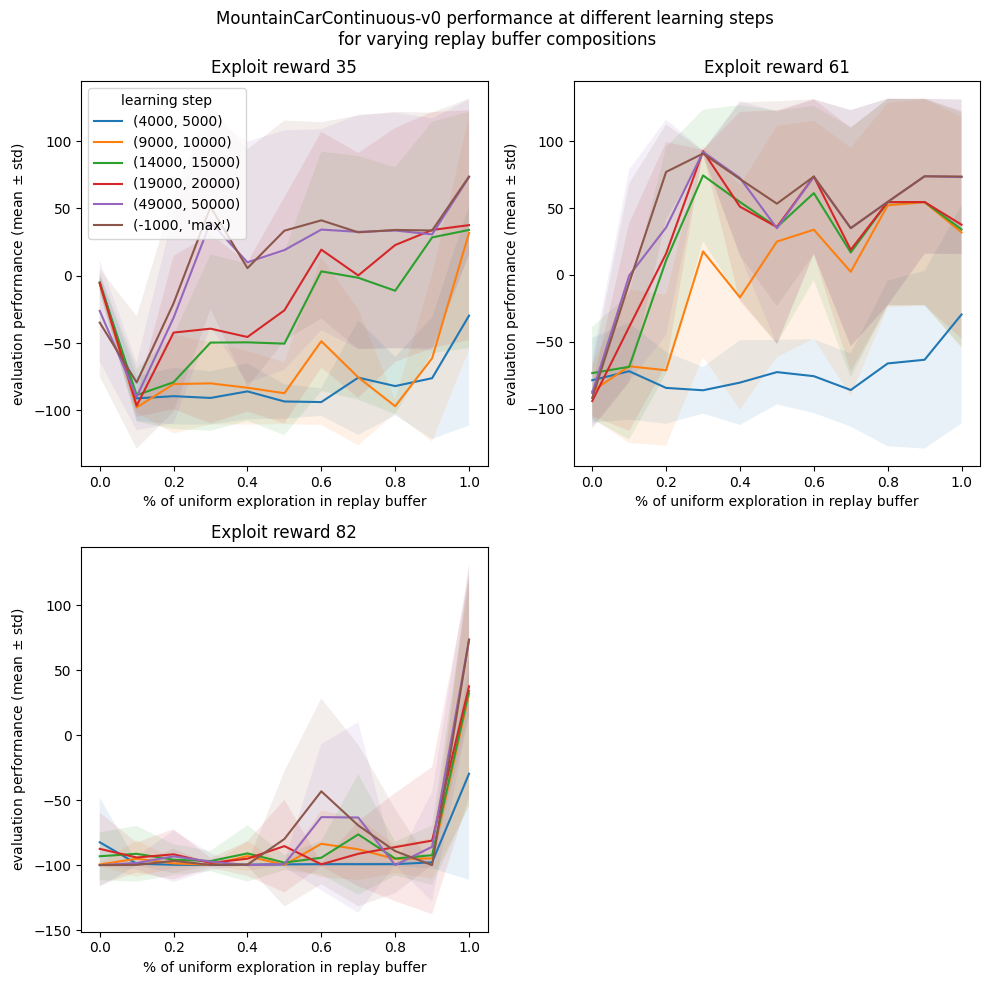

=========== NOISE_LEVELS =============


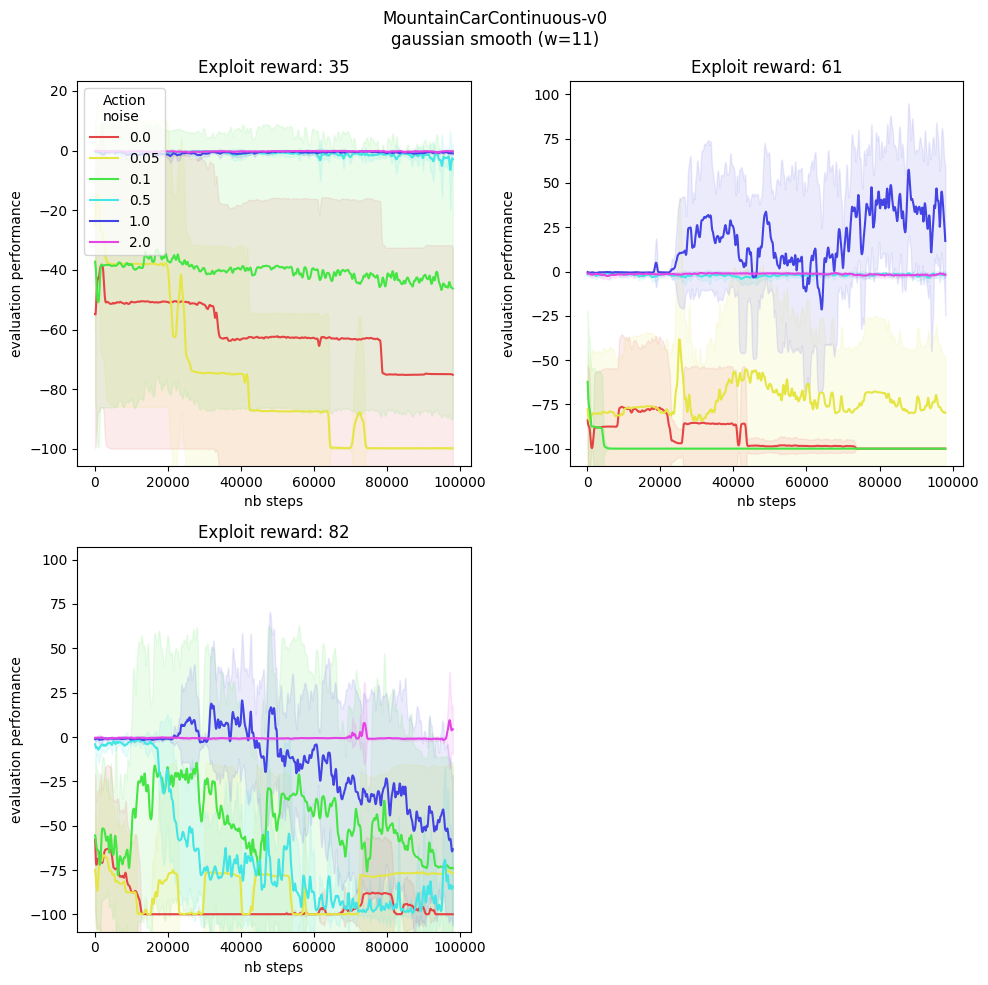

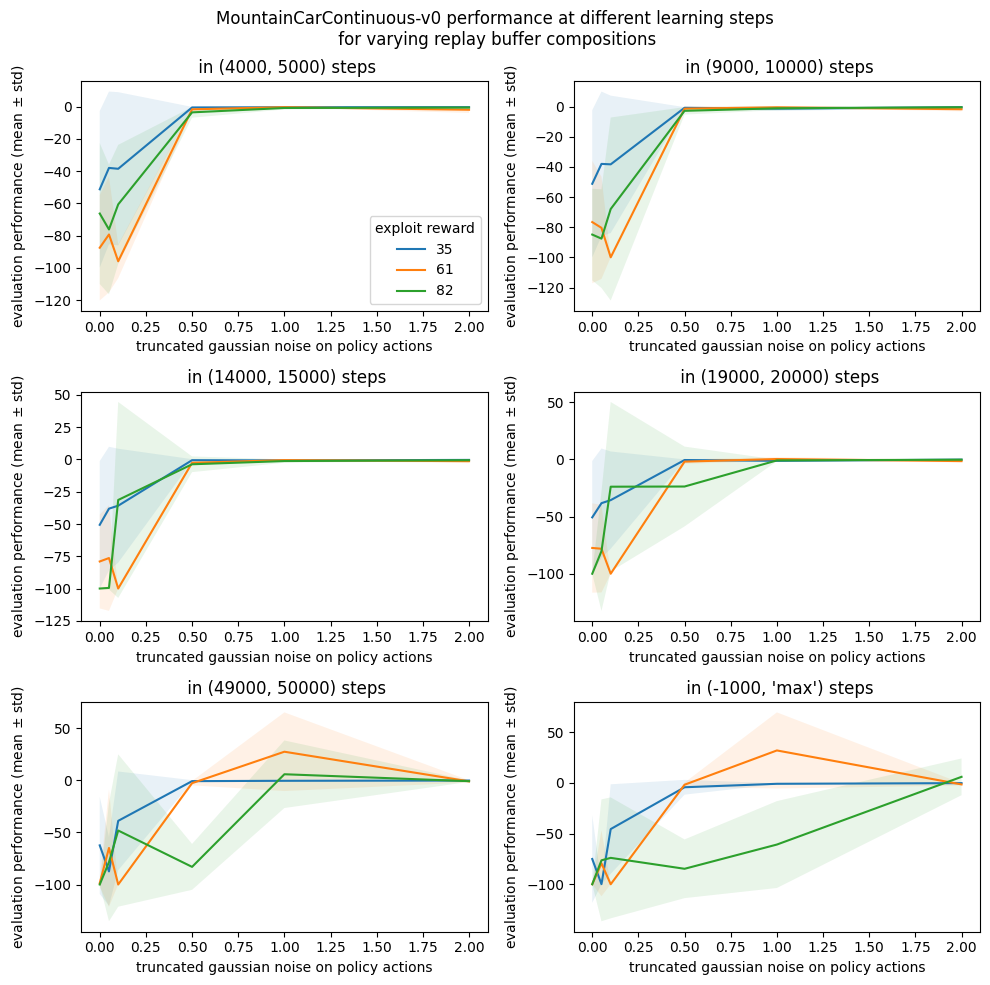

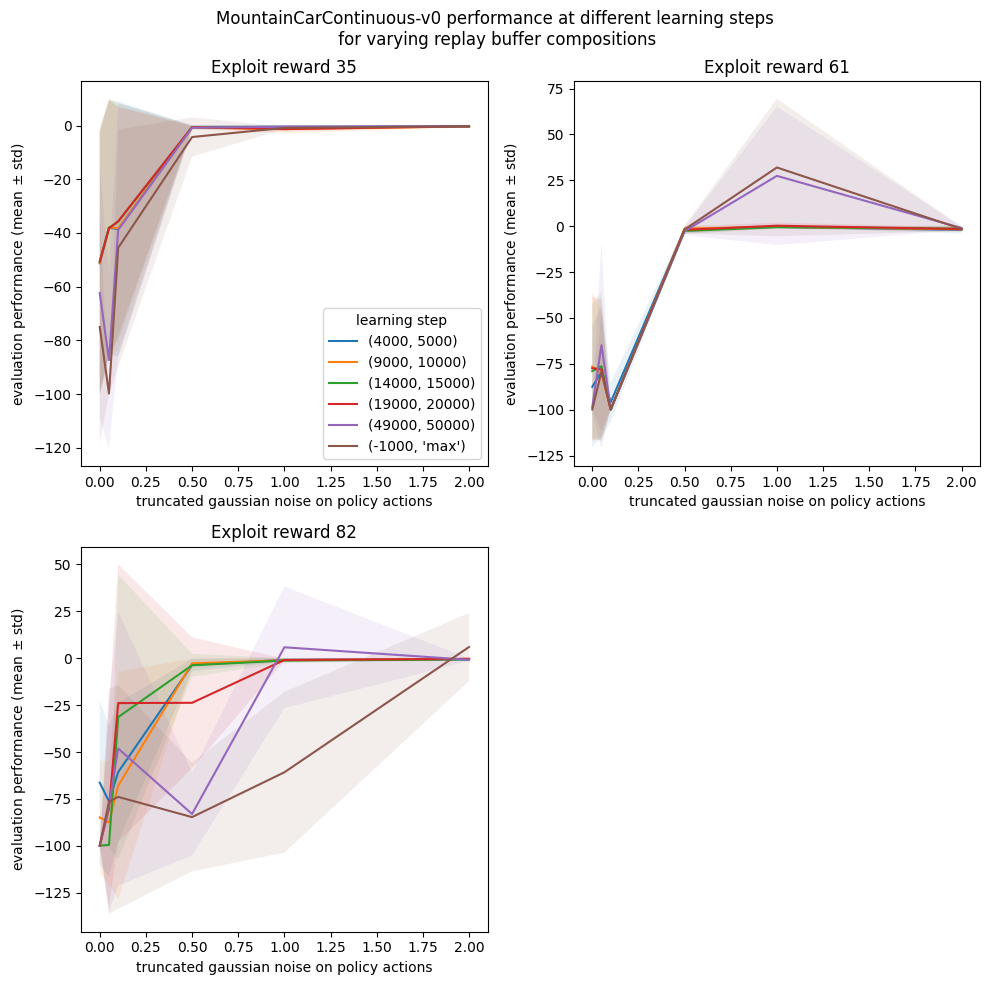

In [134]:
SMOOTH = True
SMOOTH_WINDOW = 11  # 11
SMOOTH_MODE = ("gaussian", "max")[0]
PLOT_ALL_CURVES = False
PLOT_STD = True
STEPS_TO_TAKE = [5_000, 10_000, 15_000, 20_000, 50_000, None]
LAST_STEPS = 1000  # 500
PLOT_MARGIN = 0.05


for rb_composition_type in ("uniform_proportions", "noise_levels"):
    print("===========", rb_composition_type.upper(), "=============")
    for env_name in ENV_NAMES:
        if not all_performances[rb_composition_type][env_name]:
            continue

        # ============= Learning Curves =============
        env_performances = all_performances[rb_composition_type][env_name]
        n_rewards = len(env_performances)

        ncols = 2 if n_rewards > 1 else 1
        nrows = int(np.ceil(n_rewards / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(10, 10))
        axes = np.atleast_1d(axes).flatten()

        for i_reward, reward in enumerate(sorted(env_performances)):
            plot_learning_curves(
                env_performances[reward],
                SMOOTH_MODE,
                SMOOTH_WINDOW,
                PLOT_ALL_CURVES,
                PLOT_STD,
                PLOT_MARGIN,
                ax=axes[i_reward],
            )
            axes[i_reward].set_title(f"Exploit reward: {reward}")

        for ax in axes[i_reward + 1 :]:
            fig.delaxes(ax)

        axes[0].legend(
            title="Uniform\nproportion"
            if rb_composition_type == "uniform_proportions"
            else "Action\nnoise",
            loc="upper left",
        )
        fig.suptitle(
            f"{env_name}" + f"\n{SMOOTH_MODE} smooth (w={SMOOTH_WINDOW})"
            if SMOOTH_MODE is not None
            else ""
        )
        plt.tight_layout()
        plt.show()

        # ============= Compositions By Step =============
        n_steps = len(STEPS_TO_TAKE)
        ncols = 2 if n_steps > 1 else 1
        nrows = int(np.ceil(n_steps / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(10, 10))
        axes = np.atleast_1d(axes).flatten()
        for i_step, step_to_take in enumerate(STEPS_TO_TAKE):
            for reward in sorted(env_performances):
                plot_rb_compositions(
                    env_performances[reward],
                    SMOOTH_MODE,
                    SMOOTH_WINDOW,
                    step_to_take,
                    LAST_STEPS,
                    ax=axes[i_step],
                    label=reward,
                )
            axes[i_step].set_title(
                f" in {(step_to_take-LAST_STEPS, step_to_take) if step_to_take is not None else (-LAST_STEPS,'max')} steps"
            )
        axes[0].legend(title="exploit reward")
        for ax in axes[i_step + 1 :]:
            fig.delaxes(ax)

        fig.suptitle(f"{env_name} performance at different learning steps\n for varying replay buffer compositions")
        plt.tight_layout()
        plt.show()
        
        
        # ============= Compositions By Exploit Reward =============
        n_rewards = len(env_performances)

        ncols = 2 if n_rewards > 1 else 1
        nrows = int(np.ceil(n_rewards / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(10, 10))
        axes = np.atleast_1d(axes).flatten()
        for i_reward, reward in enumerate(sorted(env_performances)):
            for i_step, step_to_take in enumerate(STEPS_TO_TAKE):
                plot_rb_compositions(
                    env_performances[reward],
                    SMOOTH_MODE,
                    SMOOTH_WINDOW,
                    step_to_take,
                    LAST_STEPS,
                    ax=axes[i_reward],
                    label= str((step_to_take-LAST_STEPS, step_to_take) if step_to_take is not None else (-LAST_STEPS,'max')),
                )
            axes[i_reward].set_title(
                f"Exploit reward {reward}"
            )
        axes[0].legend(title="learning step")
        for ax in axes[i_reward + 1 :]:
            fig.delaxes(ax)

        fig.suptitle(f"{env_name} performance at different learning steps\n for varying replay buffer compositions")
        plt.tight_layout()
        plt.show()